In [24]:
import duckdb
import os
import pandas as pd
from urllib.parse import quote
from utils import (
    get_df,
    compare_dataframes,
    write_parquet
)
from summarize_utils import time_query, setup_duckdb_views, plot_results

def myquote(text):
    return quote(text)

original_path = "./datasets_parquet/wikimedia/wikipedia/20231101.ab.parquet"
compressed_path = "./datasets_compress/wikimedia/wikipedia/20231101.ab.parquet"
original_size = os.path.getsize(original_path)
compressed_size = os.path.getsize(compressed_path)
con = duckdb.connect()
con.create_function('quote', myquote, [str], return_type=str)

In [21]:
restore_df = con.execute("""
SELECT
  id,
  SUBSTR(combine_title_text, 1, title_len) AS title,
  SUBSTR(combine_title_text, title_len + 1) AS text,
  'https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len)) AS url
FROM compress_df
""").fetchdf()
print(restore_df.head)

<bound method NDFrame.head of          id                                              title  \
0       807                                       Аԥсуа бызшәа   
1      1040                                               Аҟәа   
2      1044                                      Аԥсуа алфавит   
3      1046                                              Гагра   
4      1053                                  Аԥсны Аҳәынҭқарра   
...     ...                                                ...   
6147  37256                                            Мальдив   
6148  37258                                             Мианма   
6149  37263                                     Аԥсны Афырхаҵа   
6150  37268                                    Бӷажәба Хәыхәыт   
6151  37269  АГТРК (Аԥснытәи аҳәынҭкарратә телерадиоеилахәыра)   

                                                   text  \
0     А́ԥсуа бызшәа́, аԥсшәа (, ) — Аԥсны ҳәынҭқарра...   
1     А́ҟәа () — Аԥсны Аҳәынҭқарра  аҳҭнықалақь. Аҟә...   


In [25]:
# Query timings
setup_duckdb_views(con, original_path, compressed_path)

In [26]:
t1 = time_query(con, "SUMMARIZE SELECT title, text, url FROM original")
t2 = time_query(con, "SUMMARIZE SELECT SUBSTR(combine_title_text, 1, title_len) AS title, SUBSTR(combine_title_text, title_len + 1) AS text, 'https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len)) AS url FROM virtual")
print(f"Original query time: {t1:.4f} seconds")
print(f"Compressed query time: {t2:.4f} seconds")

  column_name column_type                                                min  \
0       title     VARCHAR                                                  1   
1        text     VARCHAR  \n\n\n\nБакы (1967): Бакынтәи аметрополитен — ...   
2         url     VARCHAR               https://ab.wikipedia.org/wiki/%CE%91   

                                                 max  approx_unique   avg  \
0                                                  Ꚙ           5484  <NA>   
1  Ꚙ, ꚙ — кириллтәи аҩыратә архаикатә иажәхьоу нб...           2536  <NA>   
2              https://ab.wikipedia.org/wiki/YouTube           8539  <NA>   

    std   q25   q50   q75  count  null_percentage  
0  <NA>  <NA>  <NA>  <NA>   6152              0.0  
1  <NA>  <NA>  <NA>  <NA>   6152              0.0  
2  <NA>  <NA>  <NA>  <NA>   6152              0.0  
  column_name column_type                                                min  \
0       title     VARCHAR                                                  1   
1 

In [ ]:
t5 = time_query("SUMMARIZE SELECT title_len AS length(title), LENGTH(combine_title_text) - title_len AS length(text), LENGTH('https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len))) AS length(url) FROM virtual")

In [30]:
t3 = time_query(con, "SUMMARIZE SELECT LENGTH(title), LENGTH(text), LENGTH(url) FROM original")
t4 = time_query(con, "SUMMARIZE SELECT LENGTH(SUBSTR(combine_title_text, 1, title_len)) AS 'length(title)', LENGTH(SUBSTR(combine_title_text, title_len + 1)) AS 'length(text)', LENGTH('https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len))) AS 'length(url)' FROM virtual")
t5 = time_query(con, "SUMMARIZE SELECT title_len AS 'length(title)', LENGTH(combine_title_text) - title_len AS 'length(text)', LENGTH('https://ab.wikipedia.org/wiki/' || quote(SUBSTR(combine_title_text, 1, title_len))) AS 'length(url)' FROM virtual")
print(f"Original query time: {t3:.4f} seconds")
print(f"Compressed query time: {t4:.4f} seconds")
print(f"Trick query time: {t5:.4f} seconds")

      column_name column_type min    max  approx_unique                avg  \
0   length(title)      BIGINT   1     51             45  8.755851755526658   
1  length("text")      BIGINT   1  24878            861  337.0411248374512   
2     length(url)      BIGINT  31    327            156  65.88459037711313   

                 std  q25  q50  q75  count  null_percentage  
0  6.923194886208074    4    9   10   6152              0.0  
1  1188.334007198255  181  181  181   6152              0.0  
2  42.92978023941294   34   53   83   6152              0.0  
     column_name column_type min    max  approx_unique                avg  \
0  length(title)      BIGINT   1     51             45  8.755851755526658   
1   length(text)      BIGINT   1  24878            861  337.0411248374512   
2    length(url)      BIGINT  31    327            156  65.88459037711313   

                 std  q25  q50  q75  count  null_percentage  
0  6.923194886208074    4    9   10   6152              0.0  
1  118

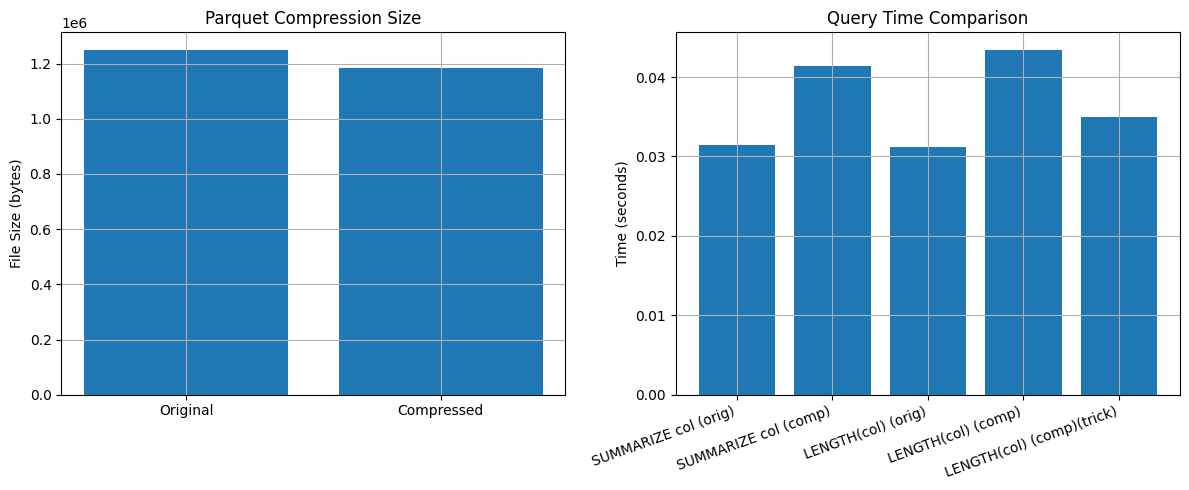

In [33]:
query_times = {
    "SUMMARIZE col (orig)": t1,
    "SUMMARIZE col (comp)": t2,
    "LENGTH(col) (orig)": t3,
    "LENGTH(col) (comp)": t4,
    "LENGTH(col) (comp)(trick)": t5
}
plot_results(original_size, compressed_size, query_times, "Wikipedia")

In [32]:
compressed_size / original_size

0.9465596917074419